In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LogNorm
import seaborn as sns
#sns.set_context('paper', font_scale=1.8) "font.family": "sans-serif","font.sans-serif": ["Helvetica"],
sns.set(style="white", context="paper", font_scale=1.8, 
        rc={"text.usetex": True, 
            'font.family':'Times New Roman', 
            'font.serif':'Times New Roman', 
            "savefig.dpi": 300})
plt.rcParams['text.usetex'] = True
def configure_axes(ax, info=None):   
    if info is not None:
        multiline_info = "\n".join(info)
        ax.text(0.2, 0.5, multiline_info, transform=ax.transAxes, fontsize=16,
                color='black', bbox=dict(facecolor='silver', alpha=0.5,
                                         edgecolor='silver', boxstyle='round,pad=0.8',
                                         linewidth=0.2))
    def set_x_label(label, size=18, labelpad=5):
        ax.set_xlabel(label, size=size, labelpad=labelpad, loc="right", fontname='serif')
    def set_y_label(label, size=18, labelpad=5):
        ax.set_ylabel(label, size=size, labelpad=labelpad, loc="top", fontname='serif')
    def set_legend(framealpha=0.5, fontsize='16'):
        ax.legend(framealpha=framealpha, loc='best', fontsize=fontsize)
    ax.set_x_label = set_x_label
    ax.set_y_label = set_y_label
    ax.minorticks_on() 
    ax.tick_params(direction='in', length=10, width=1.1, colors='black', which='major', top=True, right=True)
    ax.tick_params(direction='in', length=5, width=0.6, colors='black', which='minor', top=True, right=True)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    for spine in ['left', 'right', 'top', 'bottom']:
        ax.spines[spine].set_linewidth(1.2)
    sns.despine(left=False, bottom=False, right=False, top=False, offset=None, trim=False)
    ax.tick_params(axis='x', labelcolor='black', labelsize=16)
    ax.tick_params(axis='y', labelcolor='black', labelsize=16)
cm = mpl.colormaps['coolwarm']


# Digitalized data 

In [2]:
DFdata = pd.read_csv('fig_aux17a_digitalized_data.csv')
my1 = DFdata.iloc[:, 0].to_numpy()
mx = DFdata.iloc[:, 1].to_numpy()
UL_signal_strength = DFdata.iloc[:,2].to_numpy()
DFdata.head(5)


,Mediator Mass (GeV),DM Mass (GeV),Upper limit on signal strength
0,20.0,100.0,1.46
1,20.0,200.0,3.93
2,20.0,300.0,8.69
3,20.0,500.0,34.50
4,55.0,0.0,0.01


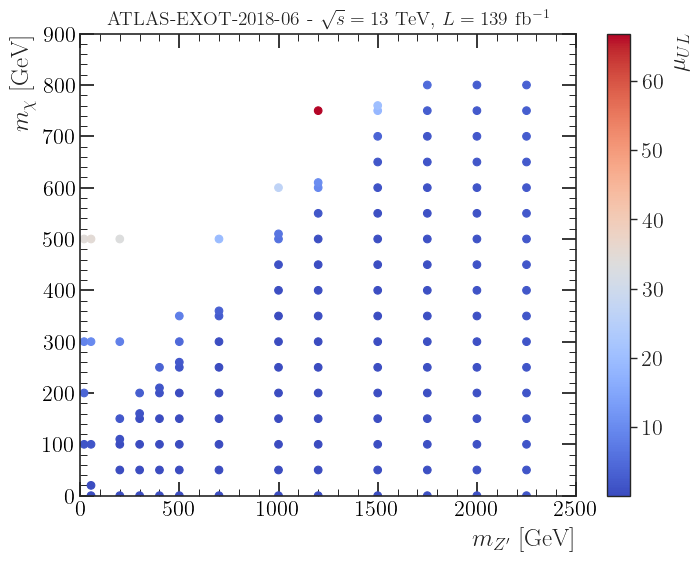

In [3]:
xsec = DFdata['Upper limit on signal strength']
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(DFdata['Mediator Mass (GeV)'], DFdata['DM Mass (GeV)'], 
                c=xsec, cmap=cm,s = 30) # vmin=5e-1, vmax=1.5e0
cbar = plt.colorbar(sc)
cbar.set_label(r'$\mu_{UL}$', loc='top')
ax.set_x_label(r'$m_{Z^{\prime}}$ [GeV]')
ax.set_y_label(r'$m_{\chi}$ [GeV]')
ax.set_xlim(0, 2500)
ax.set_ylim(0, 900)
#ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()


# Signal Data from MadGraph5 Simulation

In [4]:
DFsignal = pd.read_csv('MG5_signal_data.csv')
DFsignal.head(5)


,Label,sigma (pb),Mediator Mass (GeV),Mediator Width (GeV),DM Mass (GeV),gAx,gAq,"BR_[-52, 52]","BR_[-5, 5]","BR_[-4, 4]","BR_[-3, 3]","BR_[-2, 2]","BR_[-1, 1]","BR_[-6, 6]"
0,Run 1,2.096800e+01,1000.0,38.646420,350.0,1.0,0.25,0.249985,0.128695,0.128695,0.128695,0.128695,0.128695,0.106541
1,Run 2,9.851400e+00,1200.0,63.983450,150.0,1.0,0.25,0.451585,0.093279,0.093279,0.093279,0.093279,0.093279,0.082020
2,Run 3,1.766500e+00,1750.0,58.066630,750.0,1.0,0.25,0.109245,0.149893,0.149893,0.149893,0.149893,0.149893,0.141290
3,Run 4,2.610400e+06,20.0,0.497359,100.0,1.0,0.25,NaN,0.200000,0.200000,0.200000,0.200000,0.200000,NaN
4,Run 5,2.611200e+06,20.0,0.497359,300.0,1.0,0.25,NaN,0.200000,0.200000,0.200000,0.200000,0.200000,NaN


# Merged data


In [5]:
merged_df = pd.merge(DFsignal,DFdata, on=['Mediator Mass (GeV)', 'DM Mass (GeV)'], how='inner')
merged_df = merged_df.drop_duplicates(subset=['Label'])
merged_df.head(5)


,Label,sigma (pb),Mediator Mass (GeV),Mediator Width (GeV),DM Mass (GeV),gAx,gAq,"BR_[-52, 52]","BR_[-5, 5]","BR_[-4, 4]","BR_[-3, 3]","BR_[-2, 2]","BR_[-1, 1]","BR_[-6, 6]",Upper limit on signal strength
0,Run 1,2.096800e+01,1000.0,38.646420,350.0,1.0,0.25,0.249985,0.128695,0.128695,0.128695,0.128695,0.128695,0.106541,0.27
1,Run 2,9.851400e+00,1200.0,63.983450,150.0,1.0,0.25,0.451585,0.093279,0.093279,0.093279,0.093279,0.093279,0.082020,0.20
2,Run 3,1.766500e+00,1750.0,58.066630,750.0,1.0,0.25,0.109245,0.149893,0.149893,0.149893,0.149893,0.149893,0.141290,2.63
3,Run 4,2.610400e+06,20.0,0.497359,100.0,1.0,0.25,NaN,0.200000,0.200000,0.200000,0.200000,0.200000,NaN,1.46
4,Run 5,2.611200e+06,20.0,0.497359,300.0,1.0,0.25,NaN,0.200000,0.200000,0.200000,0.200000,0.200000,NaN,8.69


### Cross-section

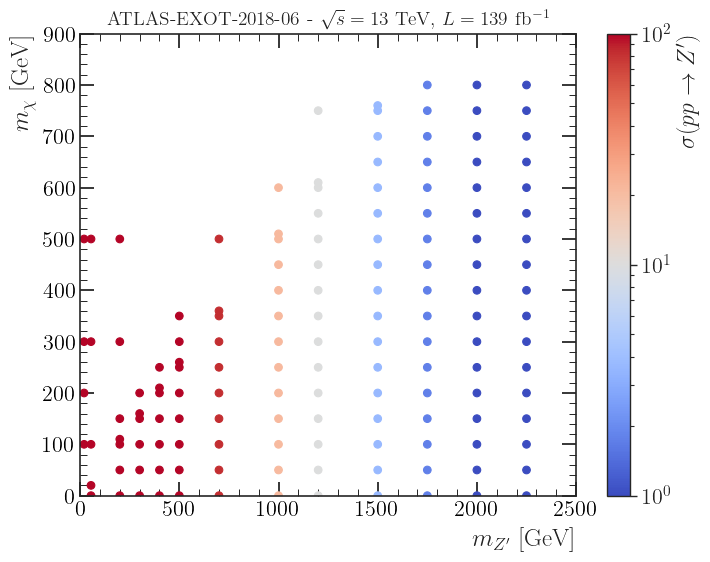

In [6]:
xsec = merged_df['sigma (pb)']
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(merged_df['Mediator Mass (GeV)'], merged_df['DM Mass (GeV)'], 
                c=xsec, cmap=cm,s = 30, norm = LogNorm(1,1e2)) # vmin=5e-1, vmax=1.5e0
cbar = plt.colorbar(sc)
cbar.set_label(r'$\sigma(p p \to Z^\prime)$', loc='top')
ax.set_x_label(r'$m_{Z^{\prime}}$ [GeV]')
ax.set_y_label(r'$m_{\chi}$ [GeV]')
ax.set_xlim(0, 2500)
ax.set_ylim(0, 900)
#ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()


### Branching ratio


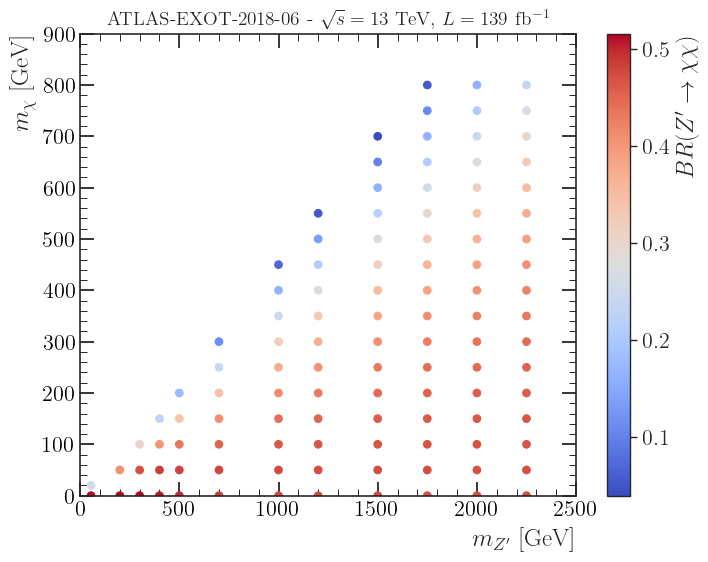

In [7]:
br = merged_df['BR_[-52, 52]']
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(merged_df['Mediator Mass (GeV)'], merged_df['DM Mass (GeV)'], c=br, cmap=cm,s = 30) # vmin=5e-1, vmax=1.5e0
cbar = plt.colorbar(sc)
cbar.set_label(r'$BR(Z^\prime \to \chi \chi)$', loc='top')
ax.set_x_label(r'$m_{Z^{\prime}}$ [GeV]')
ax.set_y_label(r'$m_{\chi}$ [GeV]')
ax.set_xlim(0, 2500)
ax.set_ylim(0, 900)
#ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()


# $\frac{\Gamma_{Z^{\prime}}}{m_{Z^{\prime}}}$

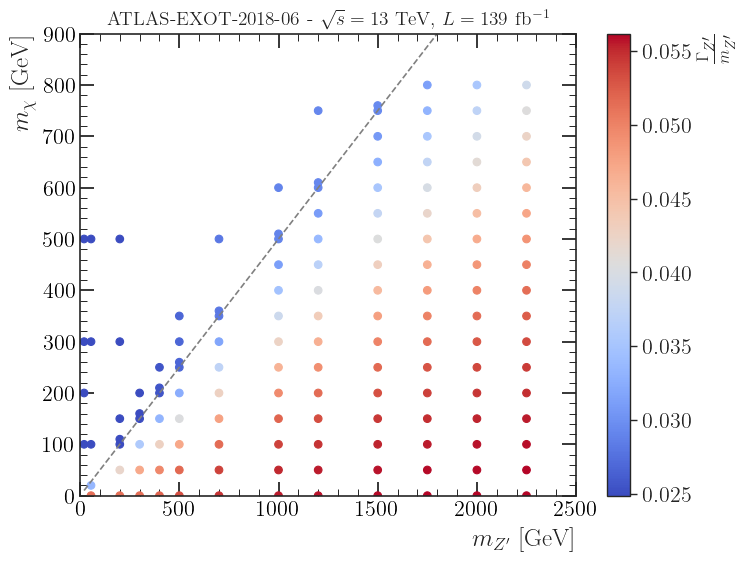

In [8]:
width_mass_ratio = merged_df['Mediator Width (GeV)'] / merged_df['Mediator Mass (GeV)']
x = np.linspace(20, 2500, 1000)
y = x / 2
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(merged_df['Mediator Mass (GeV)'], merged_df['DM Mass (GeV)'], c=width_mass_ratio, cmap=cm,s = 30) # vmin=5e-1, vmax=1.5e0
ax.plot(x, y, color='gray', linestyle='--', label=r'$m_{Z^{\prime}} = 2 m_{\chi}$')
cbar = plt.colorbar(sc)
cbar.set_label(r'$\frac{\Gamma_{Z^{\prime}}}{m_{Z^{\prime}}}$', loc='top')
ax.set_x_label('$m_{Z^{\prime}}$ [GeV]')
ax.set_y_label('$m_{\chi}$ [GeV]')
ax.set_xlim(0, 2500)
ax.set_ylim(0, 900)
#ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()


#### Exclude points with $BR(Z^\prime \to \chi \chi) = 0$

In [9]:
merged_df = merged_df.dropna(subset=["BR_[-52, 52]"])
merged_df.head(5)


,Label,sigma (pb),Mediator Mass (GeV),Mediator Width (GeV),DM Mass (GeV),gAx,gAq,"BR_[-52, 52]","BR_[-5, 5]","BR_[-4, 4]","BR_[-3, 3]","BR_[-2, 2]","BR_[-1, 1]","BR_[-6, 6]",Upper limit on signal strength
0,Run 1,20.9680,1000.0,38.64642,350.0,1.0,0.25,0.249985,0.128695,0.128695,0.128695,0.128695,0.128695,0.106541,0.27
1,Run 2,9.8514,1200.0,63.98345,150.0,1.0,0.25,0.451585,0.093279,0.093279,0.093279,0.093279,0.093279,0.082020,0.20
2,Run 3,1.7665,1750.0,58.06663,750.0,1.0,0.25,0.109245,0.149893,0.149893,0.149893,0.149893,0.149893,0.141290,2.63
5,Run 6,1.7683,1750.0,81.00442,450.0,1.0,0.25,0.361478,0.107448,0.107448,0.107448,0.107448,0.107448,0.101281,0.78
6,Run 7,1552.5000,300.0,10.75558,100.0,1.0,0.25,0.306371,0.138726,0.138726,0.138726,0.138726,0.138726,NaN,0.04


# $\frac{\Gamma_{Z^{\prime}}}{m_{Z^{\prime}}}$

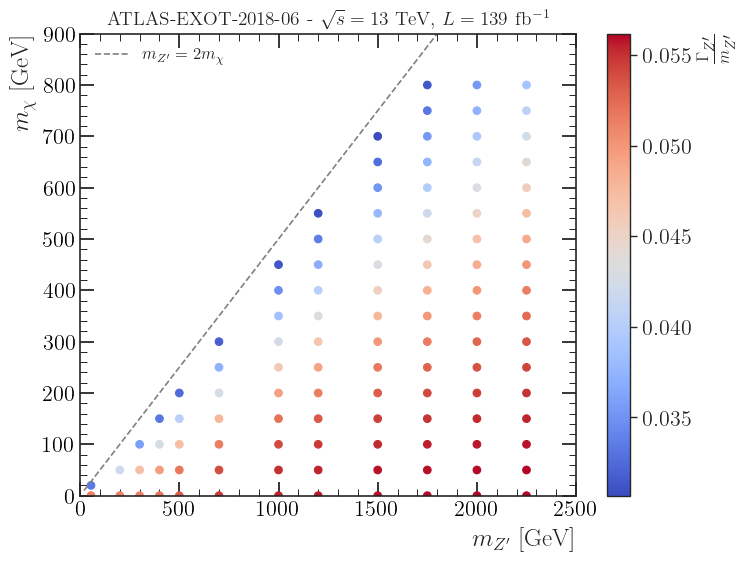

In [10]:
width_mass_ratio = merged_df['Mediator Width (GeV)'] / merged_df['Mediator Mass (GeV)']

fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(merged_df['Mediator Mass (GeV)'], merged_df['DM Mass (GeV)'], c=width_mass_ratio, cmap=cm,s = 30) # vmin=5e-1, vmax=1.5e0
ax.plot(x, y, color='gray', linestyle='--', label=r'$m_{Z^{\prime}} = 2 m_{\chi}$')
cbar = plt.colorbar(sc)
cbar.set_label(r'$\frac{\Gamma_{Z^{\prime}}}{m_{Z^{\prime}}}$', loc='top')
ax.set_x_label('$m_{Z^{\prime}}$ [GeV]')
ax.set_y_label('$m_{\chi}$ [GeV]')
ax.set_xlim(0, 2500)
ax.set_ylim(0, 900)
ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()


# get  upper limits for $\sigma \times BR_{(Med \to \chi \chi)}$.

In [11]:
merged_df['xsecUL'] = merged_df['sigma (pb)'] * merged_df['Upper limit on signal strength']*merged_df['BR_[-52, 52]']


# DataFrame containing upper limits for $\sigma \times BR_{(Med \to \chi \chi)}$ and masses

In [12]:
new_df = merged_df[['Mediator Mass (GeV)', 'DM Mass (GeV)', 'xsecUL']]
new_headers = new_df.columns.tolist()
new_headers[0] = '# ' + new_headers[0]
new_df.columns = new_headers
#new_df = new_df.dropna() 
new_df.to_csv('sigma_upper_limit_converted.csv', index=False)
new_df.head(5)


,# Mediator Mass (GeV),DM Mass (GeV),xsecUL
0,1000.0,350.0,1.415258
1,1200.0,150.0,0.889748
2,1750.0,750.0,0.507540
5,1750.0,450.0,0.498577
6,300.0,100.0,19.025627


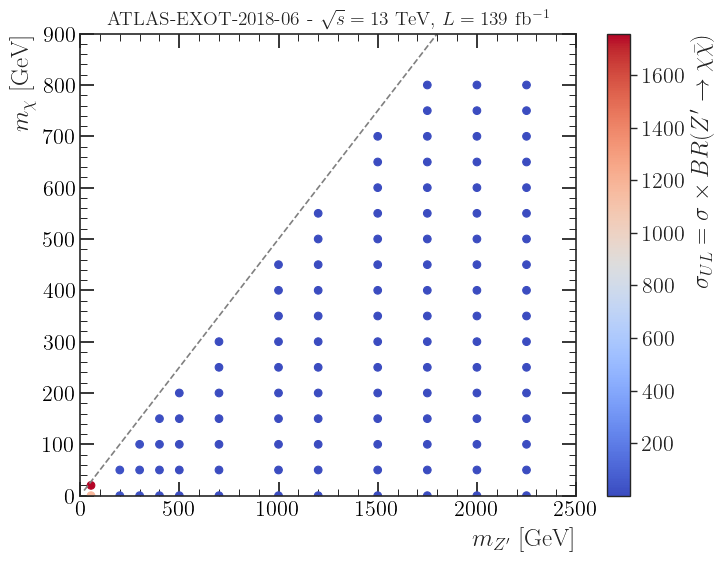

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(new_df['# Mediator Mass (GeV)'], new_df['DM Mass (GeV)'], c=new_df['xsecUL'], cmap=cm,s = 30) #, vmin = 0.3,vmax=1.0,) # 
ax.plot(x, y, color='gray', linestyle='--', label=r'$m_{Z^{\prime}} = 2 m_{\chi}$')
cbar = plt.colorbar(sc)
cbar.set_label(r'$\sigma_{UL} = \sigma \times BR(Z^{\prime}\to \chi \bar{\chi})$', loc='top')
ax.set_x_label('$m_{Z^{\prime}}$ [GeV]')
ax.set_y_label('$m_{\chi}$ [GeV]')
ax.set_xlim(0, 2500)
ax.set_ylim(0, 900)
#ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()
